In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Initialize SLM + camera and load correction file
#
# Important:
#   wavefront_phase is ONLY a NumPy array at this stage.
#   It is NOT yet installed as an SLM correction.
# ============================================================

from pathlib import Path
import numpy as np

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


# ------------------------------------------------------------
# Initialize hardware ONCE in this notebook
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)


# ------------------------------------------------------------
# Load the measured correction from disk
#
# This only creates a NumPy array called wavefront_phase.
# It does NOT activate the correction.
# ------------------------------------------------------------

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)


# ------------------------------------------------------------
# Inspect our starting state
# ------------------------------------------------------------

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)

print("\nLoaded correction:")
print(" shape :", wavefront_phase.shape)
print(" finite:", np.all(np.isfinite(wavefront_phase)))
print(" min   :", wavefront_phase.min())
print(" max   :", wavefront_phase.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())

print("\nGlobal default slm.phase_correct:")
print(slm.phase_correct)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)

Loaded correction:
 shape : (1200, 1920)
 finite: True
 min   : 0.0
 max   : 6.2831762207757835

Current slm.source keys:
dict_keys([])

Global default slm.phase_correct:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [3]:
cal_file = r"c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5"

loaded = fs.load_calibration(
    "fourier",
    file_path=cal_file
)

print("Loaded:", loaded)
print("Current calibrations:", fs.calibrations.keys())

print("Current calibrations:")
print(fs.calibrations.keys())

Loaded: c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5
Current calibrations: dict_keys(['fourier'])
Current calibrations:
dict_keys(['fourier'])


In [4]:
print("SLM:", slm)
print("Camera:", cam)
print("FourierSLM:", fs)

print("\nCurrent calibrations:")
print(fs.calibrations.keys())

SLM: <slmsuite.hardware.slms.meadowlark.Meadowlark object at 0x000002042AC8B800>
Camera: <slmsuite.hardware.cameras.alliedvision.AlliedVision object at 0x0000020429556570>
FourierSLM: <slmsuite.hardware.cameraslms.FourierSLM object at 0x000002042ADFC620>

Current calibrations:
dict_keys(['fourier'])


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

logo_path = r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Fun project\images\ydfc_logo_easy.png"

img_logo = Image.open(logo_path)

print("Image mode:", img_logo.mode)
print("Image size:", img_logo.size)

Image mode: RGBA
Image size: (659, 580)


Array shape: (898, 799)
Min value: 68
Max value: 255


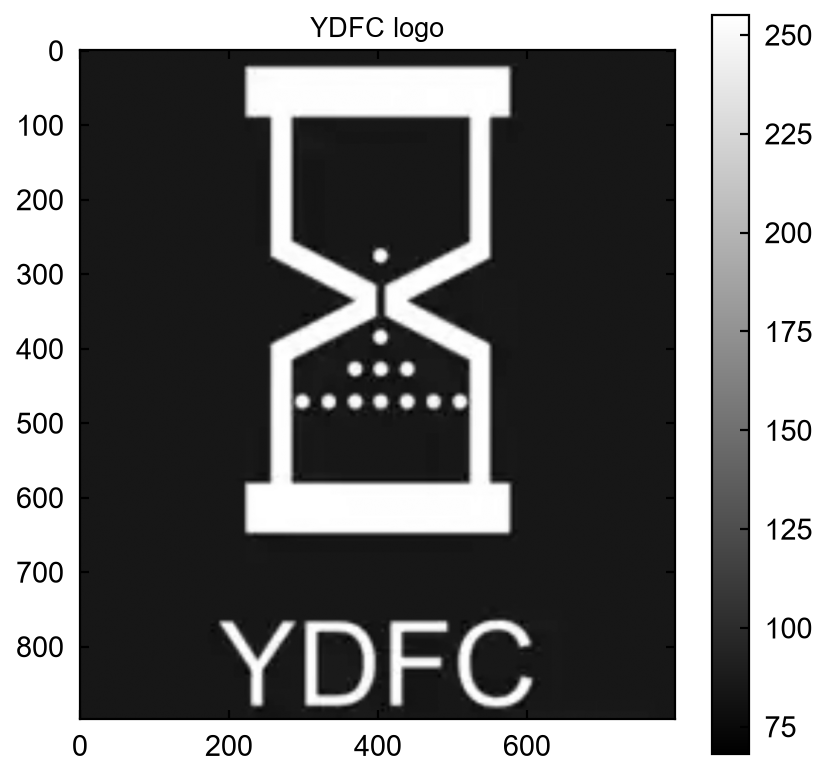

In [6]:
logo_gray = np.array(img_logo.convert("L"))

print("Array shape:", logo_gray.shape)
print("Min value:", logo_gray.min())
print("Max value:", logo_gray.max())

plt.figure(figsize=(6, 6))
plt.imshow(logo_gray, cmap="gray", origin="upper")
plt.title("YDFC logo")
plt.colorbar()
plt.show()

In [7]:
# Look at pixels around the border of the image
border = np.concatenate([
    logo_gray[0, :],
    logo_gray[-1, :],
    logo_gray[:, 0],
    logo_gray[:, -1]
])

background_level = np.median(border)

print("Estimated background level:", background_level)

Estimated background level: 85.0


In [8]:
# Convert to float between 0 and 1
logo = logo_gray.astype(np.float32) / 255.0

# If background is bright, invert it
if background_level > 127:
    logo = 1.0 - logo
    print("Bright background detected -> image inverted.")
else:
    print("Dark background detected -> no inversion.")

Dark background detected -> no inversion.


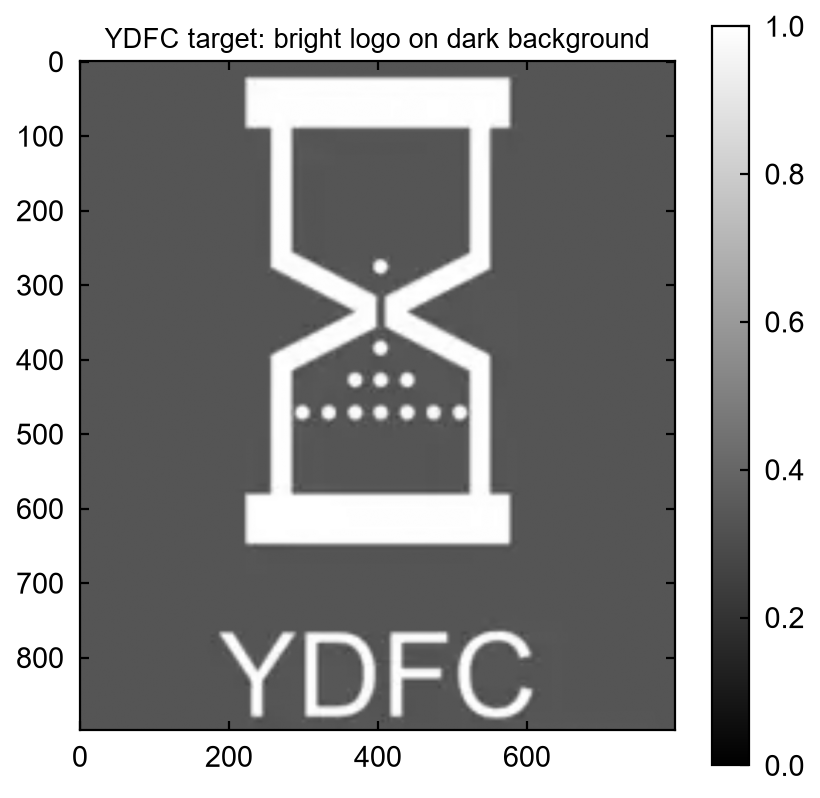

New min: 0.26666668
New max: 1.0


In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(logo, cmap="gray", origin="upper", vmin=0, vmax=1)
plt.title("YDFC target: bright logo on dark background")
plt.colorbar()
plt.show()

print("New min:", logo.min())
print("New max:", logo.max())

In [10]:
# Estimate background from the borders of the already-inverted image
border_logo = np.concatenate([
    logo[0, :],
    logo[-1, :],
    logo[:, 0],
    logo[:, -1]
])

bg = np.median(border_logo)

print("Background level:", bg)

# Subtract background and renormalize
logo_clean = (logo - bg) / (1.0 - bg)

# Anything below zero becomes zero
logo_clean = np.clip(logo_clean, 0, 1)

# Remove very weak residual background
logo_clean[logo_clean < 0.05] = 0

Background level: 0.33333334


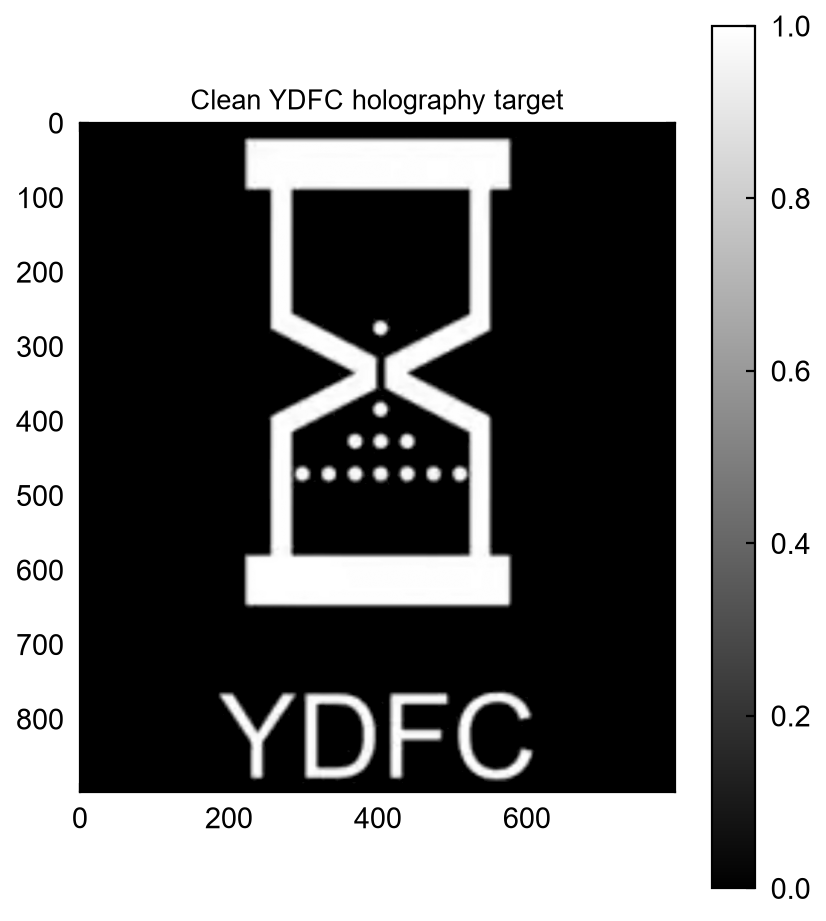

Min: 0.0
Max: 1.0


In [11]:
plt.figure(figsize=(6, 7))

plt.imshow(
    logo_clean,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=1
)

plt.title("Clean YDFC holography target")
plt.colorbar()

plt.show()

print("Min:", logo_clean.min())
print("Max:", logo_clean.max())

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Camera size
H, W = fs.cam.shape

# Zeroth-order position from calibration
zero_ij = np.asarray(fs.kxyslm_to_ijcam((0, 0))).reshape(-1)
x0 = float(zero_ij[0])
y0 = float(zero_ij[1])

print("Zero order:")
print("x0 =", x0)
print("y0 =", y0)

# --------------------------------------------------
# Choose where the logo should appear
# --------------------------------------------------
cx = int(x0 - 700)   # 700 px left of zero order
cy = int(y0)

# --------------------------------------------------
# Resize logo while keeping aspect ratio
# --------------------------------------------------
logo_h = 700
orig_h, orig_w = logo_clean.shape
logo_w = int(round(logo_h * orig_w / orig_h))

logo_resized = cv2.resize(
    logo_clean,
    (logo_w, logo_h),
    interpolation=cv2.INTER_AREA
)

print("Resized logo shape:", logo_resized.shape)

# --------------------------------------------------
# Make full camera target and paste the logo into it
# --------------------------------------------------
target_ij = np.zeros((H, W), dtype=np.float32)

x1 = int(cx - logo_w // 2)
x2 = x1 + logo_w
y1 = int(cy - logo_h // 2)
y2 = y1 + logo_h

target_ij[y1:y2, x1:x2] = logo_resized

Zero order:
x0 = 4366.832330787704
y0 = 1826.7950847761629
Resized logo shape: (700, 623)


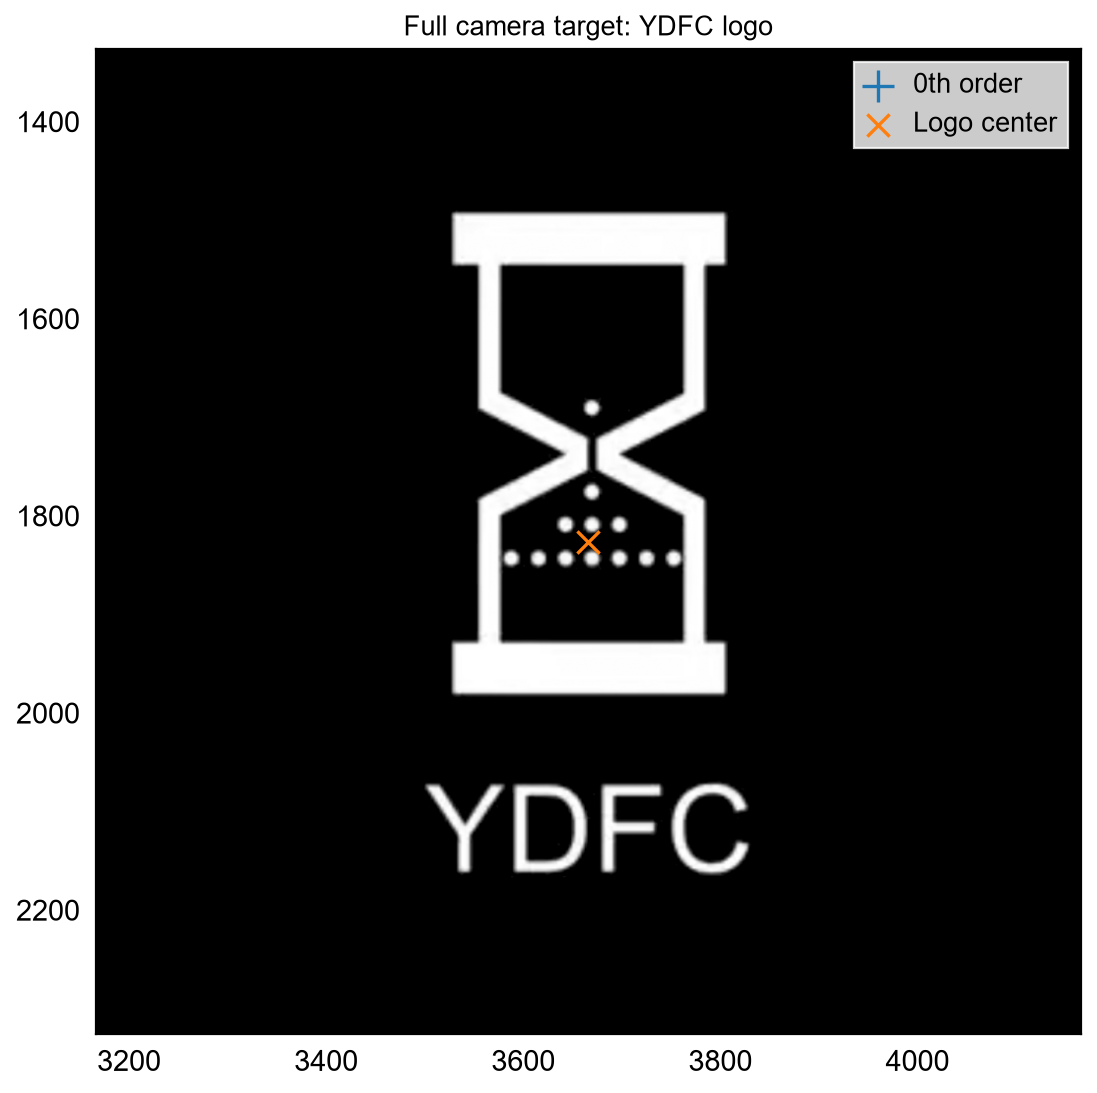

In [13]:
plt.figure(figsize=(10, 8))
plt.imshow(target_ij, cmap="gray", origin="upper")
plt.scatter(x0, y0, marker="+", s=200, label="0th order")
plt.scatter(cx, cy, marker="x", s=100, label="Logo center")
plt.xlim(cx - 500, cx + 500)
plt.ylim(cy + 500, cy - 500)
plt.legend()
plt.title("Full camera target: YDFC logo")
plt.show()

In [14]:
from slmsuite.holography.algorithms import FeedbackHologram

holo_ydfc = FeedbackHologram(
    shape=fs.slm.shape,
    target_ij=target_ij,
    cameraslm=fs
)

print("YDFC hologram object created.")
print("SLM shape:", fs.slm.shape)
print("Camera target shape:", target_ij.shape)

YDFC hologram object created.
SLM shape: (1200, 1920)
Camera target shape: (3672, 5496)


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:379: UserWarning: Hologram target shape (1200, 1920) is not a power of 2; consider using .get_padded_shape() to pad to powers of 2 and speed up FFT computation. While some FFT solvers support other prime powers (3, 5, 7, ...), literature suggests that GPU support is best for powers of 2.
  warnings.warn(


In [15]:
holo_ydfc.reset_phase(quadratic_phase=2)

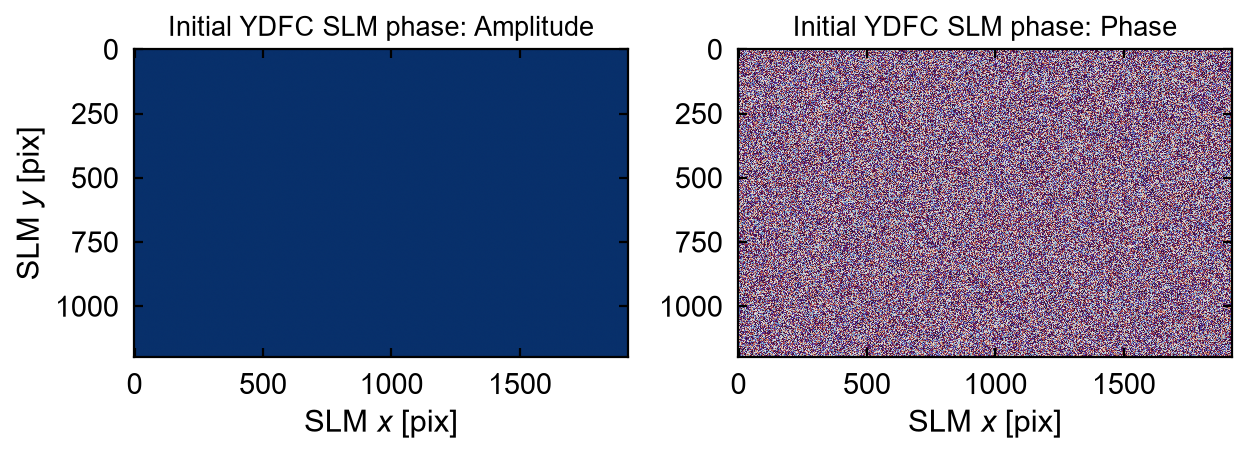

In [16]:
holo_ydfc.plot_nearfield(title="Initial YDFC SLM phase")

In [17]:
holo_ydfc.optimize(
    method="WGS-Leonardo",
    maxiter=20,
    feedback="computational",
    stat_groups=["computational"]
)

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:1837: RuntimeWarning: divide by zero encountered in divide
  xp.divide(feedback_corrected, xp.array(target_amp, copy=(False if np.__version__[0] == '1' else None)), out=feedback_corrected)


In [18]:
phase_ydfc = holo_ydfc.get_phase()

print("All finite:", np.all(np.isfinite(phase_ydfc)))
print("NaNs:", np.isnan(phase_ydfc).sum())
print("Infs:", np.isinf(phase_ydfc).sum())

All finite: True
NaNs: 0
Infs: 0


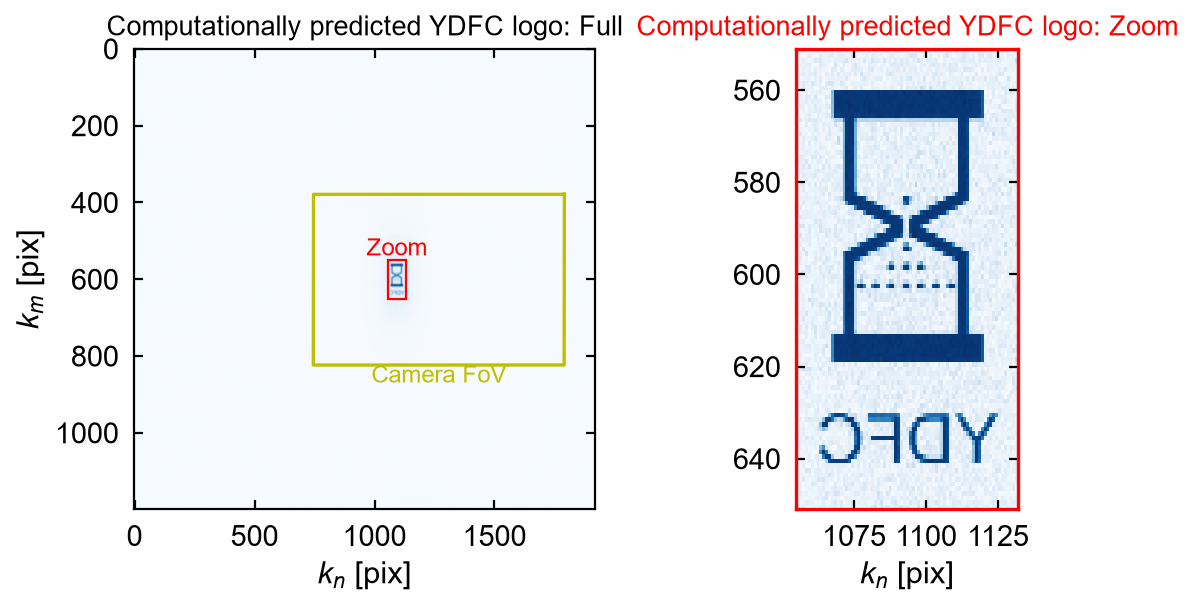

[array([1055, 1132]), array([551, 651])]

In [19]:
holo_ydfc.plot_farfield(
    title="Computationally predicted YDFC logo"
)

In [20]:
phase_ydfc = holo_ydfc.get_phase()

fs.slm.set_phase(
    phase_ydfc,
    settle=True
)

array([[151, 133, 115, ..., 206, 187, 169],
       [151, 132, 114, ..., 205, 187, 169],
       [150, 132, 114, ..., 205, 187, 168],
       ...,
       [151, 133, 115, ..., 204, 186, 168],
       [151, 133, 115, ..., 205, 187, 169],
       [151, 133, 115, ..., 205, 187, 169]],
      shape=(1200, 1920), dtype=uint8)

In [21]:
fs.cam.flush()
img_ydfc = fs.cam.get_image()

print("Image shape:", img_ydfc.shape)
print("Min:", img_ydfc.min())
print("Max:", img_ydfc.max())

Image shape: (3672, 5496)
Min: 0
Max: 255


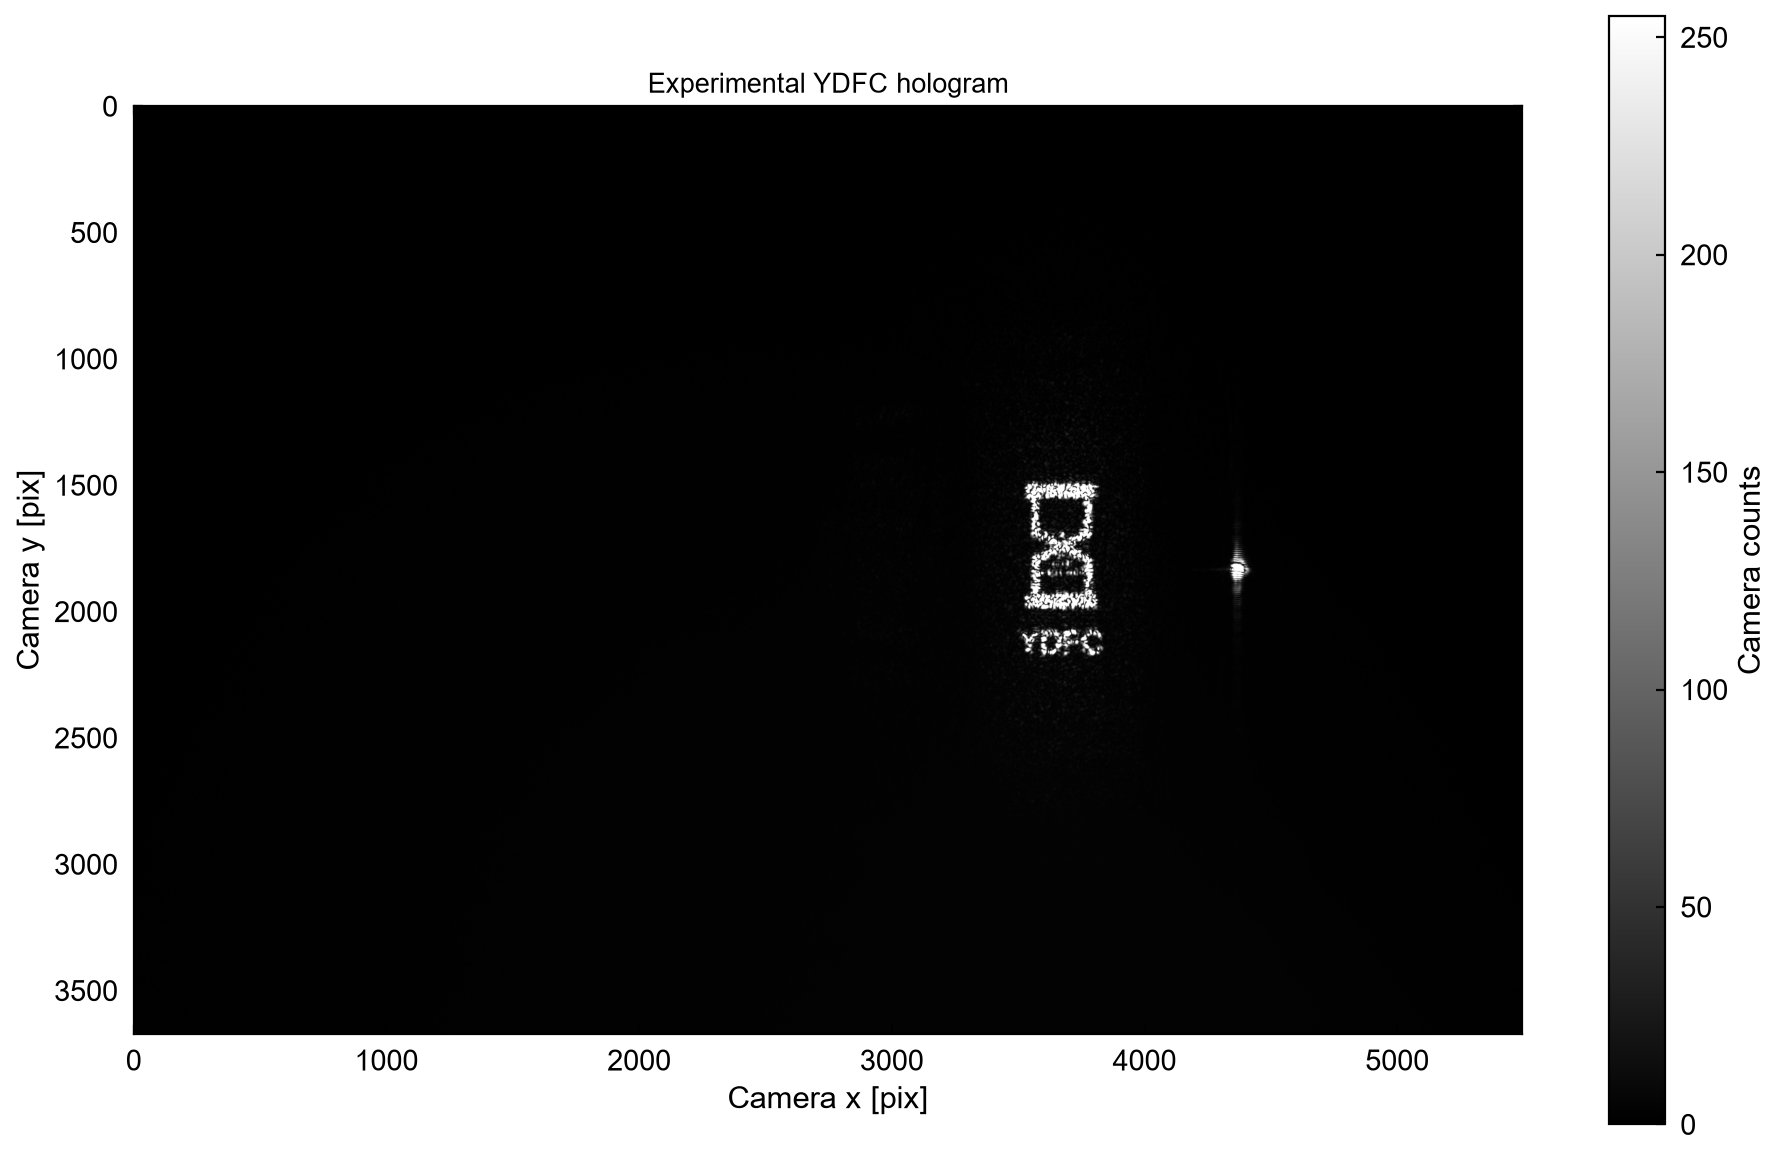

In [22]:
plt.figure(figsize=(14, 9))

plt.imshow(
    img_ydfc,
    cmap="gray",
    origin="upper"
)

plt.colorbar(label="Camera counts")
plt.title("Experimental YDFC hologram")
plt.xlabel("Camera x [pix]")
plt.ylabel("Camera y [pix]")

plt.show()

In [23]:
holo_ydfc.optimize(
    method="WGS-Leonardo",
    maxiter=50,
    feedback="computational",
    stat_groups=["computational"]
)

  0%|          | 0/50 [00:00<?, ?it/s]

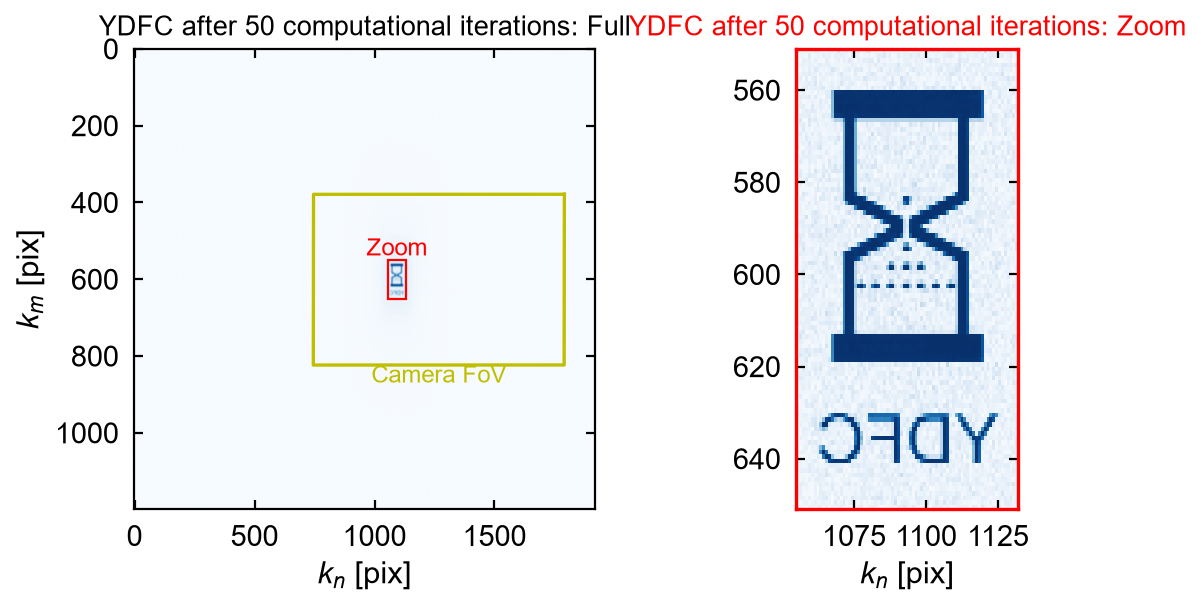

[array([1055, 1132]), array([551, 651])]

In [24]:
holo_ydfc.plot_farfield(
    title="YDFC after 50 computational iterations"
)

In [58]:
phase_ydfc_50 = holo_ydfc.get_phase()

fs.slm.set_phase(
    phase_ydfc_50,
    settle=True
)

array([[148, 129, 110, ..., 205, 186, 167],
       [147, 128, 109, ..., 205, 186, 166],
       [146, 127, 108, ..., 204, 185, 165],
       ...,
       [149, 131, 112, ..., 204, 186, 168],
       [149, 131, 112, ..., 205, 186, 168],
       [149, 130, 111, ..., 205, 187, 168]],
      shape=(1200, 1920), dtype=uint8)

In [59]:
fs.cam.flush()
img_ydfc_50 = fs.cam.get_image()

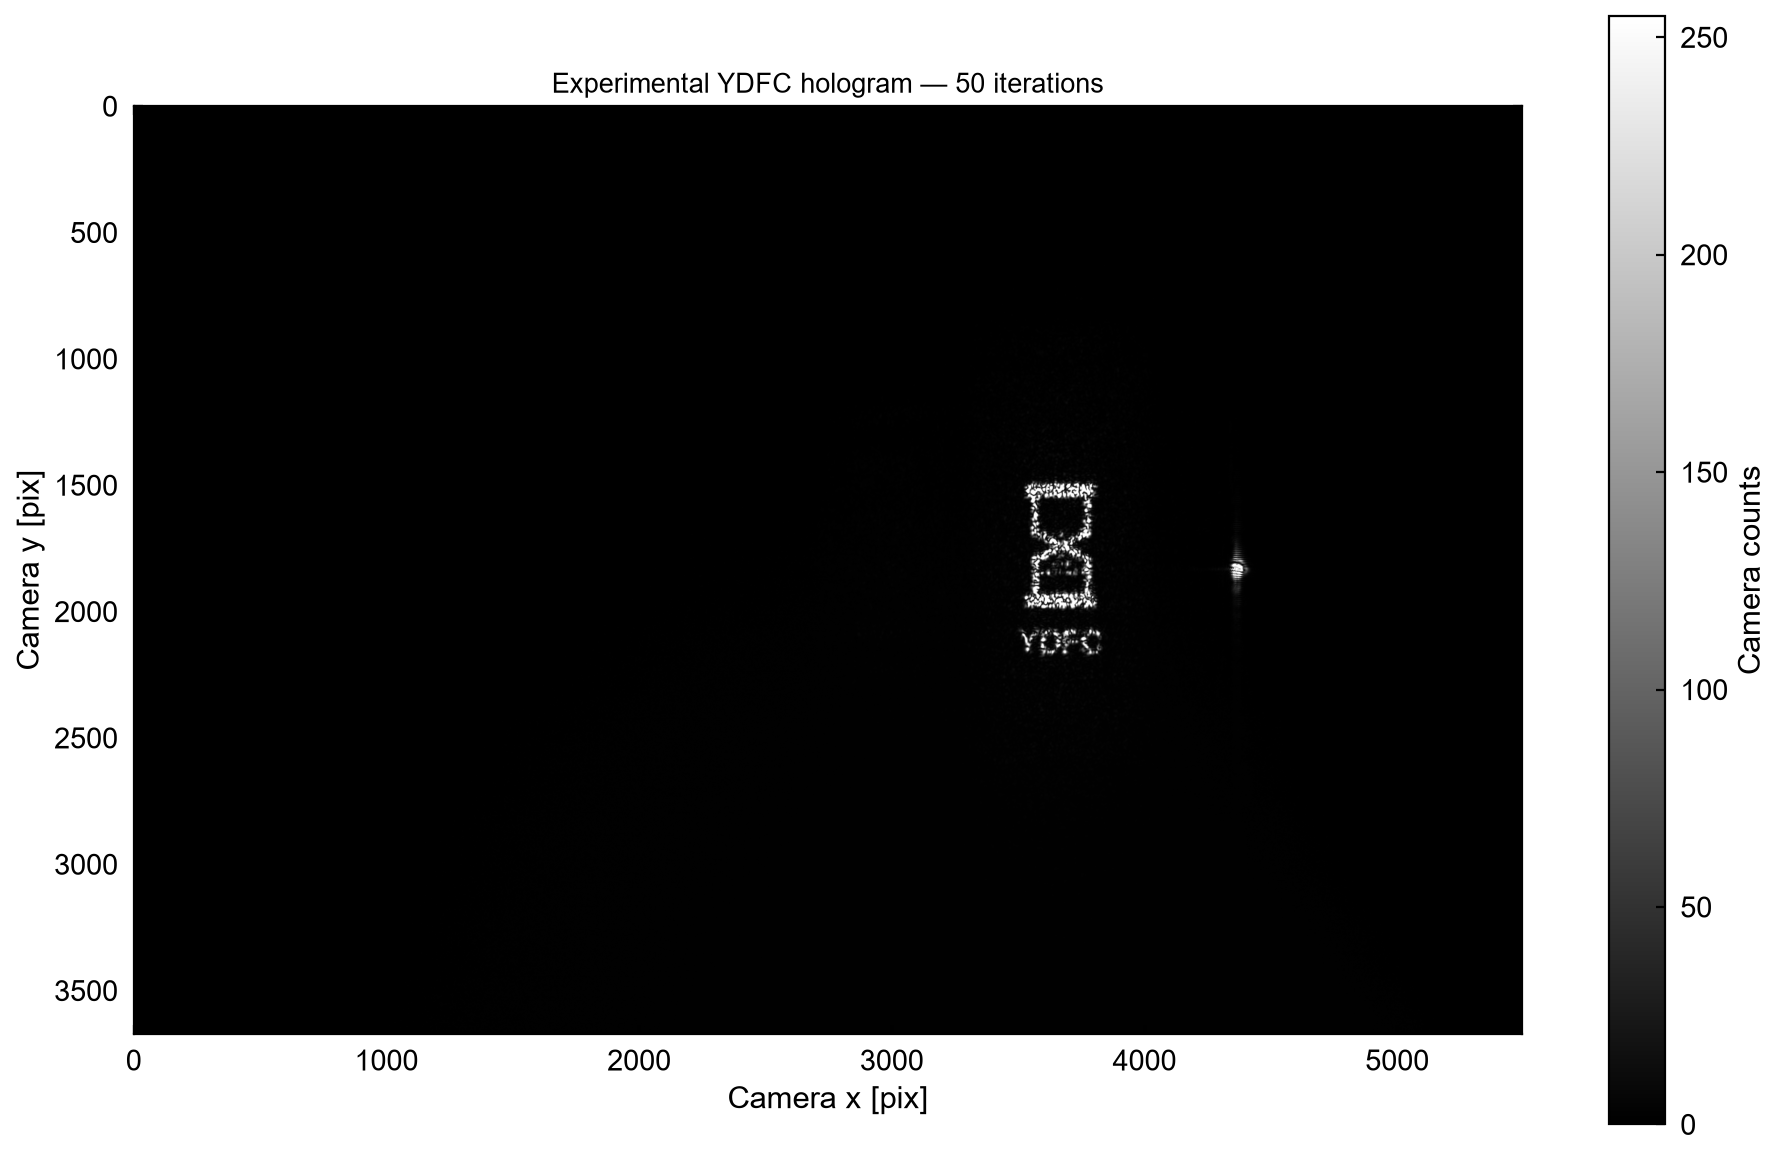

In [60]:
plt.figure(figsize=(14, 9))
plt.imshow(img_ydfc_50, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.title("Experimental YDFC hologram — 50 iterations")
plt.xlabel("Camera x [pix]")
plt.ylabel("Camera y [pix]")
plt.show()

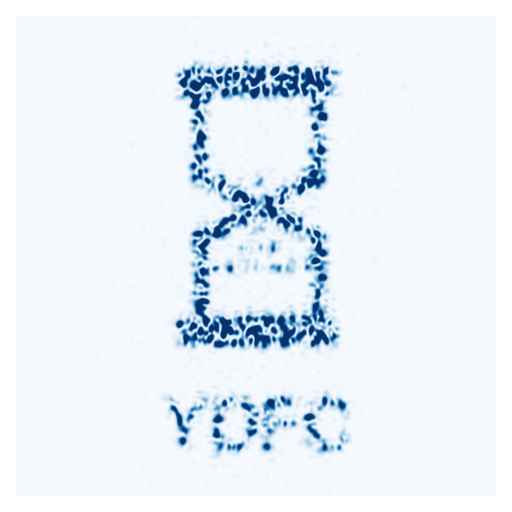

In [62]:
# Square crop around the logo
half_size = 420

x1_crop = max(0, int(cx - half_size))
x2_crop = min(img_ydfc_50.shape[1], int(cx + half_size))

y1_crop = max(0, int(cy - half_size))
y2_crop = min(img_ydfc_50.shape[0], int(cy + half_size))

img_crop_sq = img_ydfc_50[y1_crop:y2_crop, x1_crop:x2_crop]

plt.figure(figsize=(3,3))
plt.imshow(
    img_crop_sq,
    cmap="Blues",
    origin="upper"
)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [42]:
print("Current exposure [s]:", fs.cam.get_exposure())

Current exposure [s]: 0.0050071809999999994


In [50]:
exp_now = fs.cam.get_exposure()
fs.cam.set_exposure(exp_now / 1)

print("New exposure [s]:", fs.cam.get_exposure())

New exposure [s]: 0.002504681


In [45]:
fs.cam.flush()
img_test = fs.cam.get_image()

print("Min:", img_test.min())
print("Max:", img_test.max())

Min: 0
Max: 255
